# KAMP GMST-Power Phase 1 — EDA + 기획서 검증 + CV 스플릿
입력: `../5. 자원 최적화 AI 데이터셋/okm_15min_2021.csv` (Task 1 산출물). Spec: `../document/KAMP_GMST_Power_project_proposal.md`. 독립 검증: `../document/KAMP_GMST_Power_proposal_review.md` §2, 부록 A.

## 0. 데이터 로드 + 결측치 점검 + 파생 컬럼

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import date, datetime, timedelta

plt.rcParams["font.family"] = "NanumSquare"
plt.rcParams["axes.unicode_minus"] = False

SRC = "../5. 자원 최적화 AI 데이터셋/okm_15min_2021.csv"
OUT_SPLITS = "../5. 자원 최적화 AI 데이터셋/okm_cv_splits_2021.csv"

df = pl.read_csv(SRC)
print(df.shape)
print(df.null_count())
assert df.null_count()["강수량"][0] == 4, "강수량 null 개수가 예상(4)과 다름"


(24672, 9)
shape: (1, 9)
┌──────────┬──────┬────────┬──────┬───┬──────┬────────┬────────────────┬────────┐
│ datetime ┆ 전력 ┆ 생산량 ┆ 기온 ┆ … ┆ 습도 ┆ 강수량 ┆ 전기요금(계절) ┆ 인건비 │
│ ---      ┆ ---  ┆ ---    ┆ ---  ┆   ┆ ---  ┆ ---    ┆ ---            ┆ ---    │
│ u32      ┆ u32  ┆ u32    ┆ u32  ┆   ┆ u32  ┆ u32    ┆ u32            ┆ u32    │
╞══════════╪══════╪════════╪══════╪═══╪══════╪════════╪════════════════╪════════╡
│ 0        ┆ 0    ┆ 0      ┆ 0    ┆ … ┆ 0    ┆ 4      ┆ 0              ┆ 0      │
└──────────┴──────┴────────┴──────┴───┴──────┴────────┴────────────────┴────────┘


In [2]:
df = df.with_columns(pl.col("datetime").str.strptime(pl.Datetime, "%Y.%m.%d %H:%M:%S"))
df = df.with_columns(
    pl.col("datetime").dt.date().alias("date"),
    pl.col("datetime").dt.hour().alias("hour"),
    (pl.col("datetime").dt.hour() * 4 + pl.col("datetime").dt.minute() // 15).alias("quarter"),
    pl.col("datetime").dt.weekday().alias("weekday"),
    pl.col("datetime").dt.month().alias("month"),
).sort("datetime")

print("행 수:", df.height, "| 고유 날짜 수:", df["date"].n_unique())
assert df.height == 24672
assert df["date"].n_unique() == 257
df.head()


행 수: 24672 | 고유 날짜 수: 257


datetime,전력,생산량,기온,풍속,습도,강수량,전기요금(계절),인건비,date,hour,quarter,weekday,month
datetime[μs],i64,i64,f64,f64,i64,f64,f64,f64,date,i8,i8,i8,i8
2021-01-01 00:00:00,62,0,-3.2,2.4,71,0.0,109.8,1.5,2021-01-01,0,0,5,1
2021-01-01 00:15:00,61,0,-3.2,2.4,71,0.0,109.8,1.5,2021-01-01,0,1,5,1
2021-01-01 00:30:00,61,0,-3.2,2.4,71,0.0,109.8,1.5,2021-01-01,0,2,5,1
2021-01-01 00:45:00,61,0,-3.2,2.4,71,0.0,109.8,1.5,2021-01-01,0,3,5,1
2021-01-01 01:00:00,96,0,-4.5,1.5,77,0.0,109.8,1.5,2021-01-01,1,4,5,1


### event_id — 96포인트(quarter-of-day) 전력 벡터 완전일치 그룹
같은 날짜의 96개 전력값을 순서대로 벡터로 묶어 완전히 동일한 날짜끼리 그룹화한다. 그룹은 그룹 내 최초 날짜 순으로 `E000`, `E001`, … 번호를 매긴다. 고유 날짜도 자기 자신만의 그룹(크기 1)이 된다.

In [3]:
pat = df.sort(["date", "quarter"]).group_by("date", maintain_order=True).agg(pl.col("전력").alias("vec"))
groups = defaultdict(list)
for row in pat.iter_rows(named=True):
    groups[tuple(row["vec"])].append(row["date"])
sorted_groups = sorted(groups.values(), key=min)

event_rows = [
    {"date": d, "event_id": f"E{i:03d}", "dup_size": len(v)}
    for i, v in enumerate(sorted_groups)
    for d in v
]
event_df = pl.DataFrame(event_rows)

dup_groups = [v for v in sorted_groups if len(v) > 1]
print(f"이벤트(그룹) 수: {len(sorted_groups)}")
print(f"크기>1(중복) 그룹 수: {len(dup_groups)}, 그 그룹에 속한 날짜 수: {sum(len(v) for v in dup_groups)}")

assert len(sorted_groups) == 142, "이벤트 수가 예상(142)과 다름"
assert len(dup_groups) == 45, "중복 그룹 수가 예상(45)과 다름"
assert sum(len(v) for v in dup_groups) == 160, "중복 날짜 수가 예상(160)과 다름"


이벤트(그룹) 수: 142
크기>1(중복) 그룹 수: 45, 그 그룹에 속한 날짜 수: 160


### is_operating — 일 생산량 합 > 0

In [4]:
prod_sum = df.group_by("date").agg(pl.col("생산량").sum().alias("prod_sum"))
days = event_df.join(prod_sum, on="date").with_columns(
    (pl.col("prod_sum") > 0).alias("is_operating"),
    (pl.col("dup_size") > 1).alias("is_dup"),
).sort("date")

nonop = days.filter(~pl.col("is_operating"))["date"].to_list()
print(f"비가동일 수: {len(nonop)}")

stretches = []
start = prev = nonop[0]
for d in nonop[1:]:
    if d == prev + timedelta(days=1):
        prev = d
    else:
        stretches.append((start, prev))
        start = prev = d
stretches.append((start, prev))

print("비가동 연속 구간:")
for s, e in stretches:
    n = (e - s).days + 1
    print(f"  {s} ~ {e} ({n}일)" if n > 1 else f"  {s} (1일)")


비가동일 수: 64
비가동 연속 구간:
  2021-01-01 ~ 2021-01-03 (3일)
  2021-01-05 ~ 2021-01-06 (2일)
  2021-01-10 (1일)
  2021-01-12 ~ 2021-01-13 (2일)
  2021-01-19 ~ 2021-01-20 (2일)
  2021-01-24 (1일)
  2021-01-26 ~ 2021-01-27 (2일)
  2021-01-31 (1일)
  2021-02-07 (1일)
  2021-02-11 ~ 2021-02-14 (4일)
  2021-02-21 (1일)
  2021-02-28 ~ 2021-03-01 (2일)
  2021-03-05 (1일)
  2021-03-07 (1일)
  2021-03-12 (1일)
  2021-03-14 (1일)
  2021-03-19 (1일)
  2021-03-21 (1일)
  2021-03-26 (1일)
  2021-03-28 (1일)
  2021-03-31 (1일)
  2021-04-04 (1일)
  2021-04-11 (1일)
  2021-04-18 (1일)
  2021-04-25 (1일)
  2021-05-02 (1일)
  2021-05-09 (1일)
  2021-05-16 (1일)
  2021-05-23 (1일)
  2021-05-30 (1일)
  2021-06-06 (1일)
  2021-06-13 (1일)
  2021-06-20 (1일)
  2021-06-27 (1일)
  2021-07-04 (1일)
  2021-07-11 (1일)
  2021-07-13 (1일)
  2021-07-15 (1일)
  2021-07-18 (1일)
  2021-07-25 (1일)
  2021-07-31 ~ 2021-08-08 (9일)
  2021-08-15 (1일)
  2021-08-22 (1일)
  2021-08-29 (1일)
  2021-09-05 (1일)
  2021-09-12 (1일)


### anomaly — `시간` 컬럼 오염일(07-13, 07-15) OR 전력==0 포인트를 포함한 날(정전)

In [5]:
zero_pts = df.filter(pl.col("전력") == 0).sort("datetime")
print(f"전력==0 포인트 총 개수: {zero_pts.height}")
print(f"범위: {zero_pts['datetime'].min()} ~ {zero_pts['datetime'].max()}")

main_span = zero_pts.filter(
    (pl.col("datetime") >= datetime(2021, 8, 28, 18, 0)) & (pl.col("datetime") <= datetime(2021, 8, 29, 10, 45))
)
print(f"주 정전 구간 2021-08-28 18:00 ~ 2021-08-29 10:45 내 개수: {main_span.height} (검증보고서 참조치 68)")

other = zero_pts.filter(
    ~((pl.col("datetime") >= datetime(2021, 8, 28, 18, 0)) & (pl.col("datetime") <= datetime(2021, 8, 29, 10, 45)))
)
print(f"구간 밖 추가 0값 {other.height}개 (검증보고서에는 없음, day 단위 anomaly 플래그에는 포함):")
print(other.select("datetime", "전력", "생산량"))

corrupt_dates = {date(2021, 7, 13), date(2021, 7, 15)}
zero_days = set(zero_pts["date"].unique().to_list())
anomaly_dates = corrupt_dates | zero_days
print(f"anomaly=True 날짜 수: {len(anomaly_dates)} ->", sorted(anomaly_dates))

days = days.with_columns(pl.col("date").is_in(list(anomaly_dates)).alias("anomaly"))
days = days.join(df.select("date", "weekday", "month").unique(subset="date"), on="date").sort("date")

assert days.height == 257
assert days["event_id"].null_count() == 0
days.head()


전력==0 포인트 총 개수: 74
범위: 2021-08-28 17:30:00 ~ 2021-09-08 12:15:00
주 정전 구간 2021-08-28 18:00 ~ 2021-08-29 10:45 내 개수: 68 (검증보고서 참조치 68)
구간 밖 추가 0값 6개 (검증보고서에는 없음, day 단위 anomaly 플래그에는 포함):
shape: (6, 3)
┌─────────────────────┬──────┬────────┐
│ datetime            ┆ 전력 ┆ 생산량 │
│ ---                 ┆ ---  ┆ ---    │
│ datetime[μs]        ┆ i64  ┆ i64    │
╞═════════════════════╪══════╪════════╡
│ 2021-08-28 17:30:00 ┆ 0    ┆ 0      │
│ 2021-08-28 17:45:00 ┆ 0    ┆ 0      │
│ 2021-08-29 11:00:00 ┆ 0    ┆ 0      │
│ 2021-08-29 11:15:00 ┆ 0    ┆ 0      │
│ 2021-09-08 12:00:00 ┆ 0    ┆ 3      │
│ 2021-09-08 12:15:00 ┆ 0    ┆ 3      │
└─────────────────────┴──────┴────────┘
anomaly=True 날짜 수: 5 -> [datetime.date(2021, 7, 13), datetime.date(2021, 7, 15), datetime.date(2021, 8, 28), datetime.date(2021, 8, 29), datetime.date(2021, 9, 8)]


date,event_id,dup_size,prod_sum,is_operating,is_dup,anomaly,weekday,month
date,str,i64,i64,bool,bool,bool,i8,i8
2021-01-01,"""E000""",1,0,false,false,false,5,1
2021-01-02,"""E001""",7,0,false,true,false,6,1
2021-01-03,"""E002""",2,0,false,true,false,7,1
2021-01-04,"""E003""",4,54688,true,true,false,1,1
2021-01-05,"""E004""",15,0,false,true,false,2,1


## 1. 주요 변수 시각화

### shading 헬퍼
날짜 리스트 중 mask가 True인 연속 구간을 세로 밴드로 표시한다. 여러 패널·플롯에서 재사용한다.

In [6]:
def shade_days(ax, dates, mask, color, alpha=0.35):
    on = False
    start = None
    for i in range(len(dates)):
        m = bool(mask[i])
        if m and not on:
            start, on = dates[i], True
        if on and (not m or i == len(dates) - 1):
            end = dates[i] if m else dates[i - 1]
            ax.axvspan(start, end + timedelta(days=1), color=color, alpha=alpha, lw=0)
            on = False


### 4-패널 일별 시계열: 전력 mean, 전력 max, 생산량 sum, 기온 mean

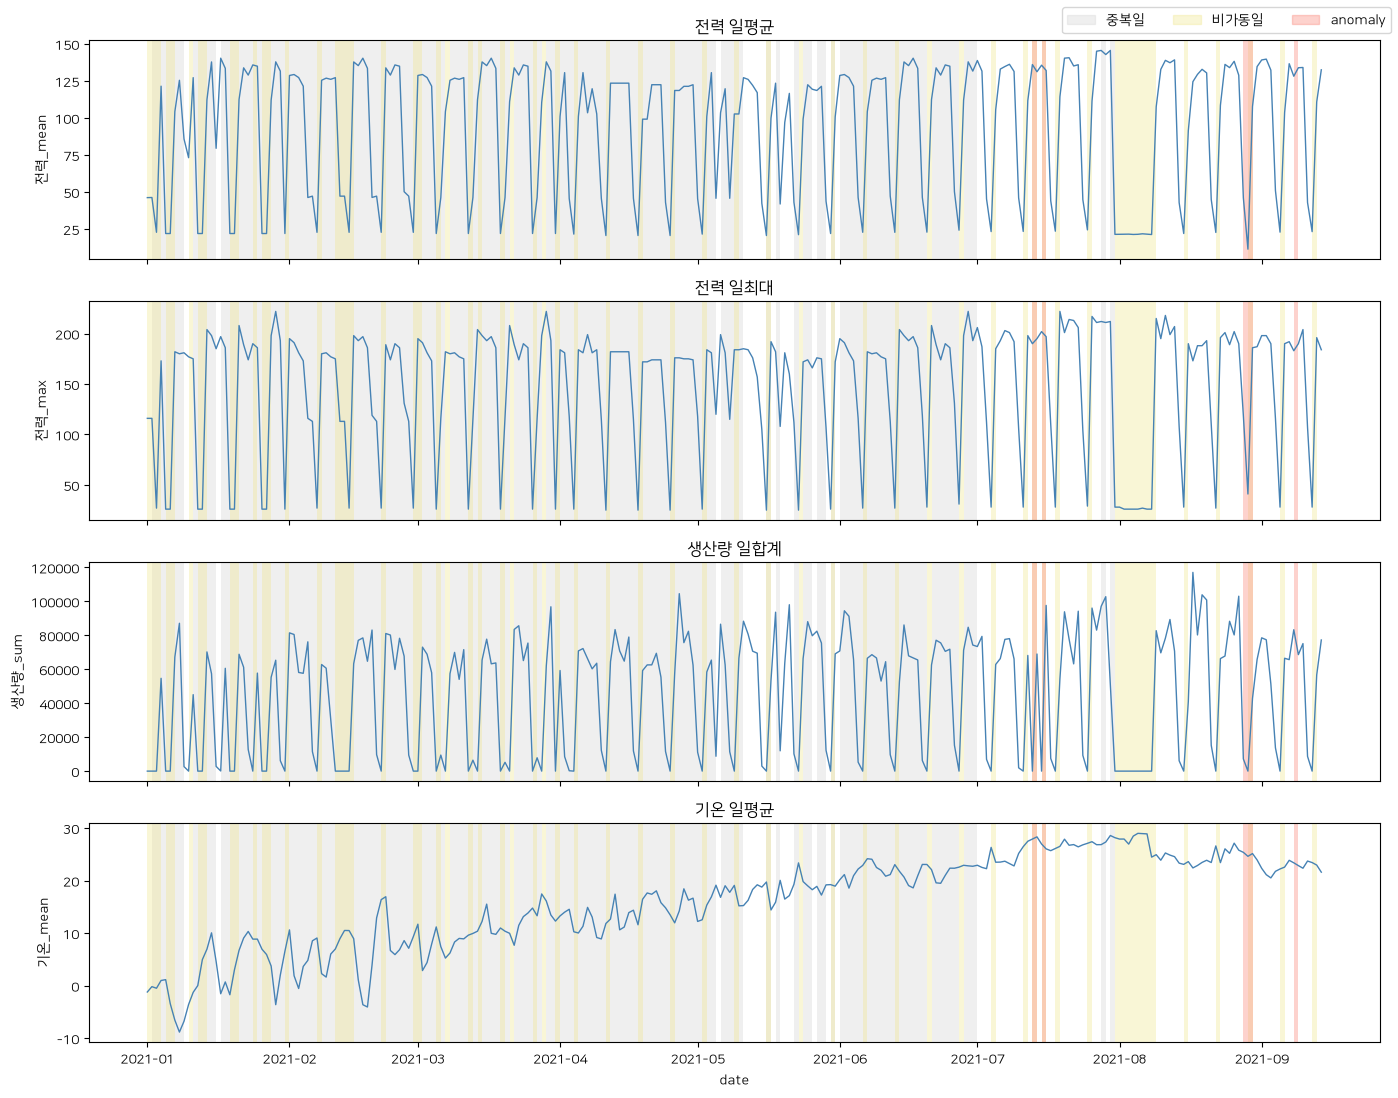

In [7]:
daily = df.group_by("date").agg(
    pl.col("전력").mean().alias("전력_mean"),
    pl.col("전력").max().alias("전력_max"),
    pl.col("생산량").sum().alias("생산량_sum"),
    pl.col("기온").mean().alias("기온_mean"),
).join(days.select("date", "is_dup", "is_operating", "anomaly"), on="date").sort("date")

dates = daily["date"].to_list()
dup_mask = daily["is_dup"].to_list()
nonop_mask = (~daily["is_operating"]).to_list()
anom_mask = daily["anomaly"].to_list()

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
panels = [("전력_mean", "전력 일평균"), ("전력_max", "전력 일최대"),
          ("생산량_sum", "생산량 일합계"), ("기온_mean", "기온 일평균")]
for ax, (col, title) in zip(axes, panels):
    ax.plot(dates, daily[col], color="steelblue", lw=1)
    shade_days(ax, dates, dup_mask, "lightgray")
    shade_days(ax, dates, nonop_mask, "khaki")
    shade_days(ax, dates, anom_mask, "salmon")
    ax.set_title(title)
    ax.set_ylabel(col)

handles = [
    plt.Rectangle((0, 0), 1, 1, color="lightgray", alpha=0.35, label="중복일"),
    plt.Rectangle((0, 0), 1, 1, color="khaki", alpha=0.35, label="비가동일"),
    plt.Rectangle((0, 0), 1, 1, color="salmon", alpha=0.35, label="anomaly"),
]
fig.legend(handles=handles, loc="upper right", ncol=3)
axes[-1].set_xlabel("date")
fig.tight_layout()
plt.show()


### 전력 박스플롯: 시간대별 / 요일별 / 월별

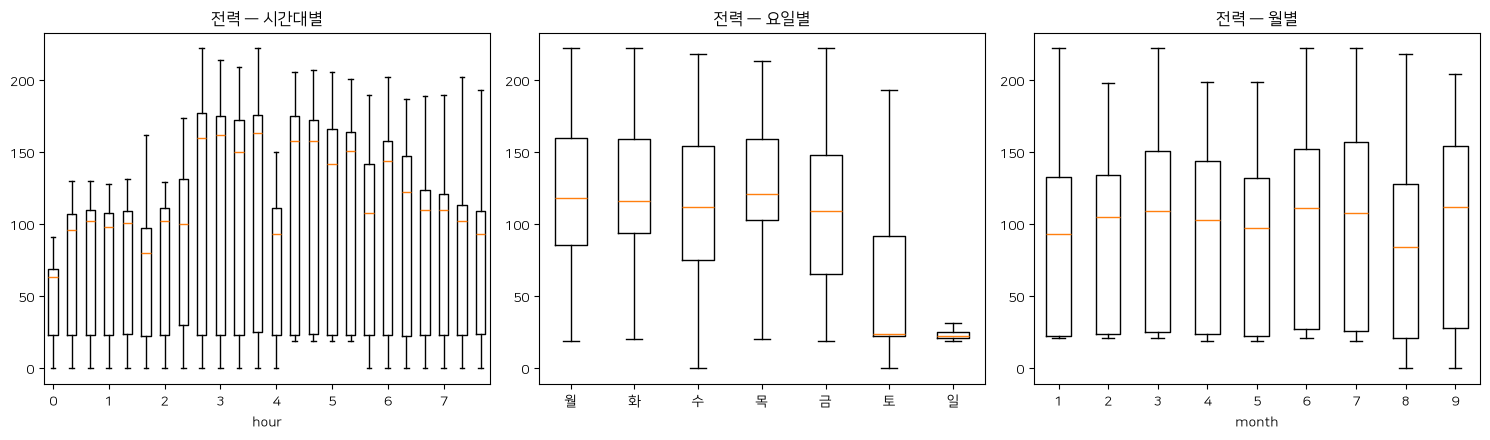

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

by_hour = [df.filter(pl.col("hour") == h)["전력"].to_numpy() for h in range(24)]
axes[0].boxplot(by_hour, positions=range(24), showfliers=False)
axes[0].set_title("전력 — 시간대별")
axes[0].set_xlabel("hour")
axes[0].set_xticks(range(0, 24, 3))

wd_labels = ["월", "화", "수", "목", "금", "토", "일"]
by_wd = [df.filter(pl.col("weekday") == w)["전력"].to_numpy() for w in range(1, 8)]
axes[1].boxplot(by_wd, positions=range(1, 8), showfliers=False)
axes[1].set_xticks(range(1, 8))
axes[1].set_xticklabels(wd_labels)
axes[1].set_title("전력 — 요일별")

months = sorted(df["month"].unique().to_list())
by_month = [df.filter(pl.col("month") == m)["전력"].to_numpy() for m in months]
axes[2].boxplot(by_month, positions=months, showfliers=False)
axes[2].set_xticks(months)
axes[2].set_title("전력 — 월별")
axes[2].set_xlabel("month")

fig.tight_layout()
plt.show()


## 2. 이중축(twinx) 플롯

### a. 일별 전력 최대(좌) vs 생산량 합계(우), 전체 기간, 중복일 음영

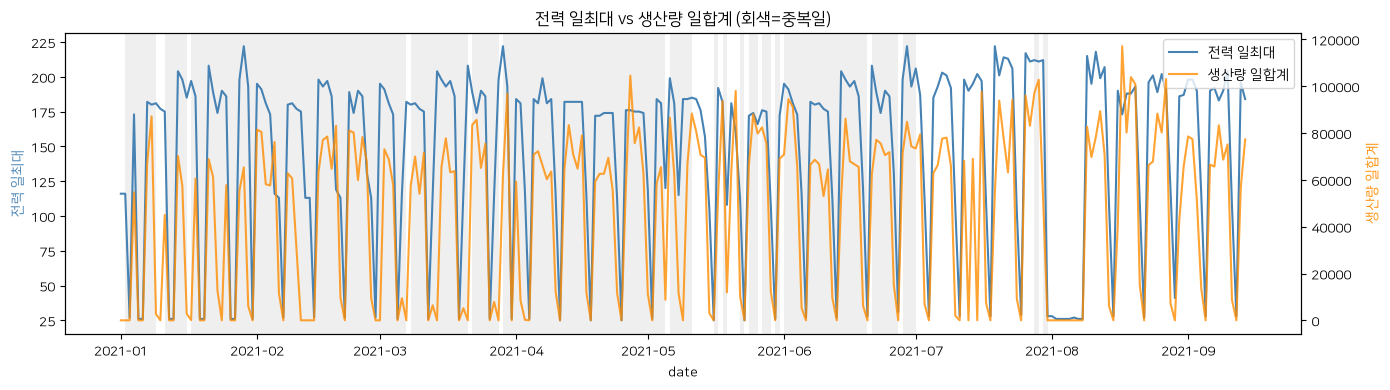

In [9]:
fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.plot(dates, daily["전력_max"], color="steelblue", label="전력 일최대")
ax2.plot(dates, daily["생산량_sum"], color="darkorange", label="생산량 일합계", alpha=0.8)
shade_days(ax1, dates, dup_mask, "lightgray")
ax1.set_ylabel("전력 일최대", color="steelblue")
ax2.set_ylabel("생산량 일합계", color="darkorange")
ax1.set_xlabel("date")
ax1.set_title("전력 일최대 vs 생산량 일합계 (회색=중복일)")
h1, lab1 = ax1.get_legend_handles_labels()
h2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, lab1 + lab2, loc="upper right")
fig.tight_layout()
plt.show()


### b. 일별 전력 평균 vs 기온 평균

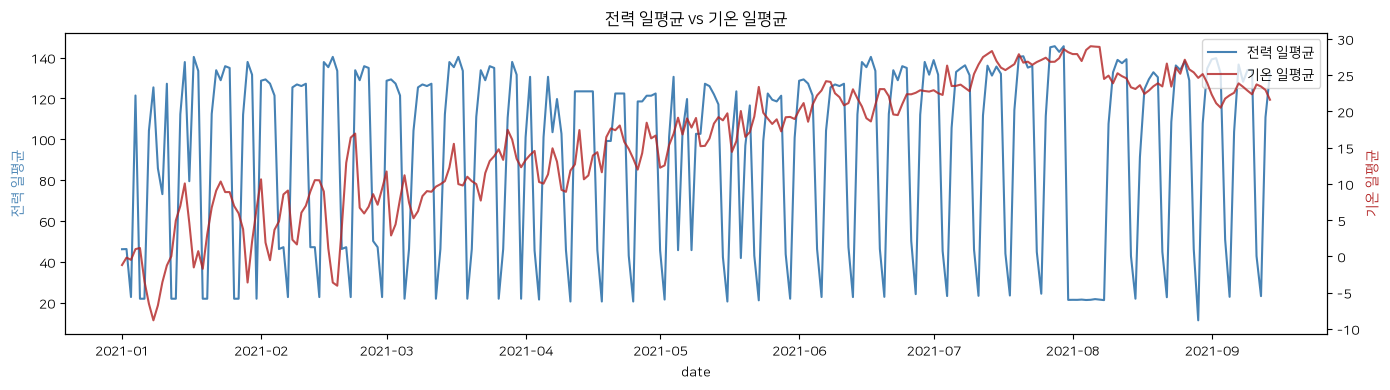

In [10]:
fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.plot(dates, daily["전력_mean"], color="steelblue", label="전력 일평균")
ax2.plot(dates, daily["기온_mean"], color="firebrick", label="기온 일평균", alpha=0.8)
ax1.set_ylabel("전력 일평균", color="steelblue")
ax2.set_ylabel("기온 일평균", color="firebrick")
ax1.set_xlabel("date")
ax1.set_title("전력 일평균 vs 기온 일평균")
h1, lab1 = ax1.get_legend_handles_labels()
h2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, lab1 + lab2, loc="upper right")
fig.tight_layout()
plt.show()


### c. 한 주(2021-09-06 ~ 09-12) 15분 해상도: 전력 vs 생산량, 인건비==1.5 음영
클린 구간(07-01~09-14) 안에서 중복일이 아닌 월~일 한 주를 고른다.

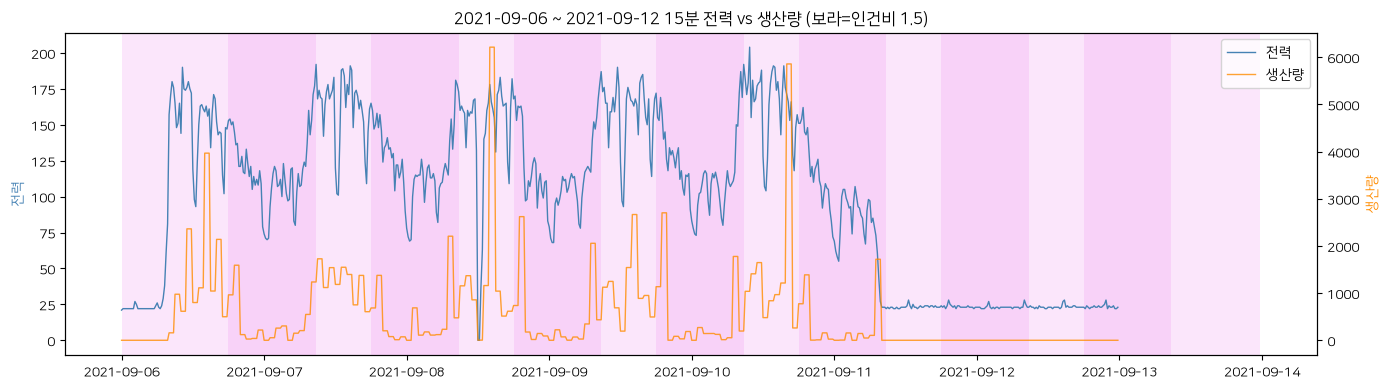

In [11]:
week_start, week_end = date(2021, 9, 6), date(2021, 9, 12)
week_dup = days.filter((pl.col("date") >= week_start) & (pl.col("date") <= week_end))["is_dup"].to_list()
if any(week_dup):
    # fallback: 클린 구간 안의 다른 중복 없는 월~일 주를 찾는다
    clean_days = days.filter((pl.col("date") >= date(2021, 7, 1)) & (pl.col("date") <= date(2021, 9, 14)))
    mondays = [d for d in clean_days["date"].to_list() if d.isoweekday() == 1]
    for m in mondays:
        w = clean_days.filter((pl.col("date") >= m) & (pl.col("date") <= m + timedelta(days=6)))
        if w.height == 7 and not w["is_dup"].any():
            week_start, week_end = m, m + timedelta(days=6)
            print(f"09-06 주가 중복일을 포함해 대체 주 사용: {week_start} ~ {week_end}")
            break
assert not any(days.filter((pl.col("date") >= week_start) & (pl.col("date") <= week_end))["is_dup"].to_list())

wk = df.filter((pl.col("date") >= week_start) & (pl.col("date") <= week_end)).sort("datetime")
fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.plot(wk["datetime"], wk["전력"], color="steelblue", label="전력", lw=1)
ax2.plot(wk["datetime"], wk["생산량"], color="darkorange", label="생산량", lw=1, alpha=0.8)
mask15 = (wk["인건비"] == 1.5).to_list()
shade_days(ax1, wk["datetime"].to_list(), mask15, "violet", alpha=0.2)
ax1.set_ylabel("전력", color="steelblue")
ax2.set_ylabel("생산량", color="darkorange")
ax1.set_title(f"{week_start} ~ {week_end} 15분 전력 vs 생산량 (보라=인건비 1.5)")
h1, lab1 = ax1.get_legend_handles_labels()
h2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, lab1 + lab2, loc="upper right")
fig.tight_layout()
plt.show()


### d. 비중복일 평균 일중 프로파일: 전력(quarter, 96pt) vs 생산량(hour)

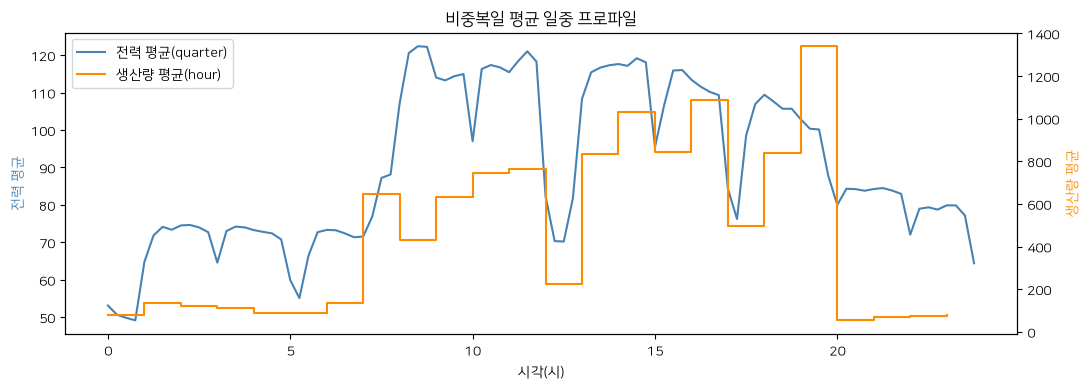

In [12]:
nondup_dates = days.filter(~pl.col("is_dup"))["date"].to_list()
sub = df.filter(pl.col("date").is_in(nondup_dates))

prof_q = sub.group_by("quarter").agg(pl.col("전력").mean().alias("전력_mean")).sort("quarter")
prof_h = sub.group_by("hour").agg(pl.col("생산량").mean().alias("생산량_mean")).sort("hour")

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()
ax1.plot(prof_q["quarter"] / 4, prof_q["전력_mean"], color="steelblue", label="전력 평균(quarter)")
ax2.plot(prof_h["hour"], prof_h["생산량_mean"], color="darkorange", label="생산량 평균(hour)", drawstyle="steps-post")
ax1.set_xlabel("시각(시)")
ax1.set_ylabel("전력 평균", color="steelblue")
ax2.set_ylabel("생산량 평균", color="darkorange")
ax1.set_title("비중복일 평균 일중 프로파일")
h1, lab1 = ax1.get_legend_handles_labels()
h2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, lab1 + lab2, loc="upper left")
fig.tight_layout()
plt.show()


### e. 월별: 전력 평균(막대, 좌) vs 전기요금(계절) 평균(선, 우)

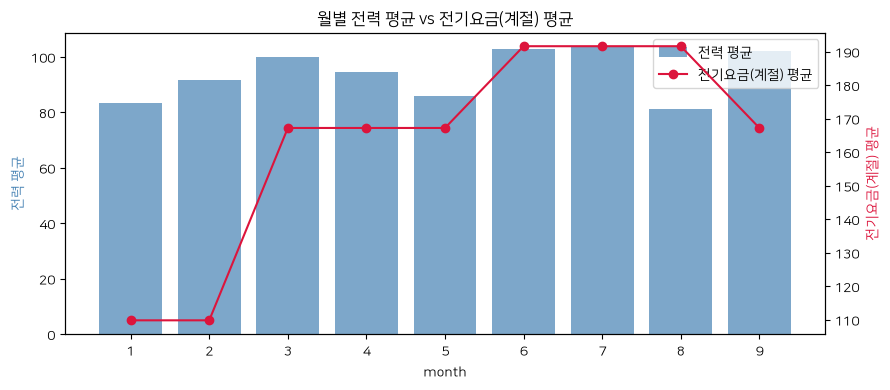

In [13]:
monthly = df.group_by("month").agg(
    pl.col("전력").mean().alias("전력_mean"),
    pl.col("전기요금(계절)").mean().alias("요금_mean"),
).sort("month")

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.bar(monthly["month"], monthly["전력_mean"], color="steelblue", alpha=0.7, label="전력 평균")
ax2.plot(monthly["month"], monthly["요금_mean"], color="crimson", marker="o", label="전기요금(계절) 평균")
ax1.set_xlabel("month")
ax1.set_ylabel("전력 평균", color="steelblue")
ax2.set_ylabel("전기요금(계절) 평균", color="crimson")
ax1.set_xticks(monthly["month"].to_list())
ax1.set_title("월별 전력 평균 vs 전기요금(계절) 평균")
h1, lab1 = ax1.get_legend_handles_labels()
h2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, lab1 + lab2, loc="upper right")
fig.tight_layout()
plt.show()


## 3. 상관관계

### 시간 단위 프레임
15분 구간 4개를 시간 단위로 평균해 전력을 만들고, 공변량들도 같은 시간 단위 평균값을 쓴다(공변량은 시간 내에서 상수이므로 평균=원값).

시간 단위 프레임: (6164, 10)


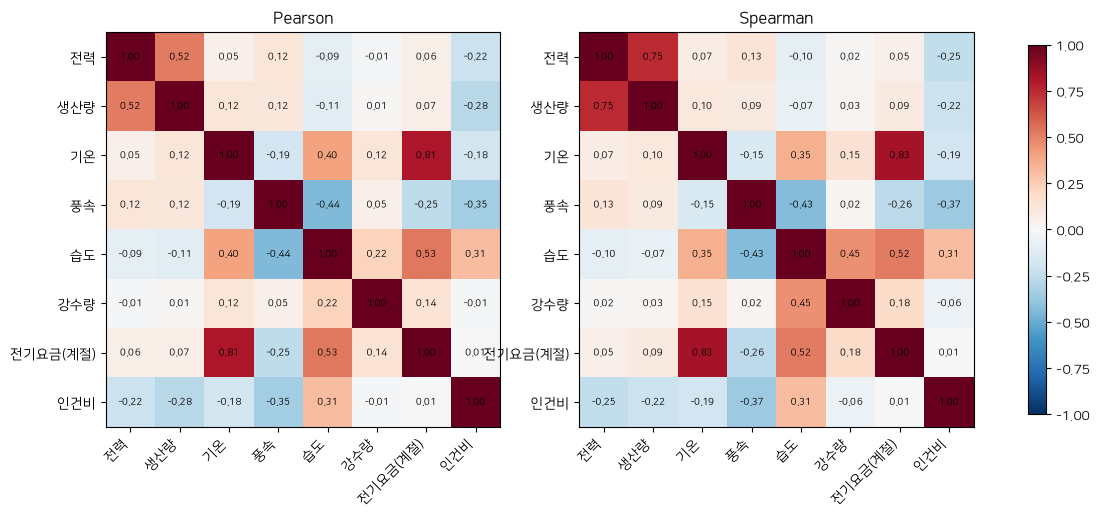

In [14]:
cols = ["전력", "생산량", "기온", "풍속", "습도", "강수량", "전기요금(계절)", "인건비"]
hourly = df.group_by(["date", "hour"]).agg([pl.col(c).mean().alias(c) for c in cols]).sort(["date", "hour"]).drop_nulls()
print("시간 단위 프레임:", hourly.shape)

mat = hourly.select(cols).to_numpy()
pearson = np.corrcoef(mat, rowvar=False)
ranks = hourly.select([pl.col(c).rank() for c in cols]).to_numpy()
spearman = np.corrcoef(ranks, rowvar=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, mat_, title in [(axes[0], pearson, "Pearson"), (axes[1], spearman, "Spearman")]:
    im = ax.imshow(mat_, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right")
    ax.set_yticks(range(len(cols)))
    ax.set_yticklabels(cols)
    ax.set_title(title)
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, f"{mat_[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()


### 교차상관: corr(전력_t, 생산량_{t-lag}), 시간 단위 lag -6..+6
양의 lag = 생산량이 전력을 선행. 전체 기간 vs 클린 구간(07-01~09-14) 비교.

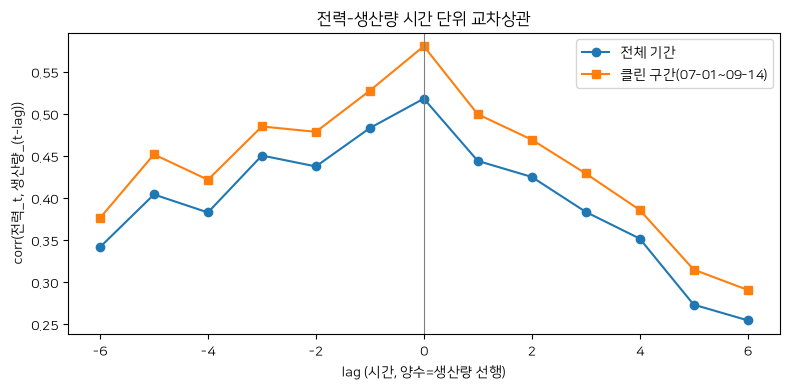

In [15]:
def xcorr(power, prod, lag):
    n = len(power)
    if lag >= 0:
        p, q = power[lag:], prod[: n - lag]
    else:
        p, q = power[: n + lag], prod[-lag:]
    return np.corrcoef(p, q)[0, 1]

lags = list(range(-6, 7))
hourly_clean = hourly.filter((pl.col("date") >= date(2021, 7, 1)) & (pl.col("date") <= date(2021, 9, 14)))

xc_all = [xcorr(hourly["전력"].to_numpy(), hourly["생산량"].to_numpy(), lag) for lag in lags]
xc_clean = [xcorr(hourly_clean["전력"].to_numpy(), hourly_clean["생산량"].to_numpy(), lag) for lag in lags]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lags, xc_all, marker="o", label="전체 기간")
ax.plot(lags, xc_clean, marker="s", label="클린 구간(07-01~09-14)")
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("lag (시간, 양수=생산량 선행)")
ax.set_ylabel("corr(전력_t, 생산량_(t-lag))")
ax.set_title("전력-생산량 시간 단위 교차상관")
ax.legend()
fig.tight_layout()
plt.show()


### ACF: 15분 전력, lag 0~672 (7일), lag 96/672 표시

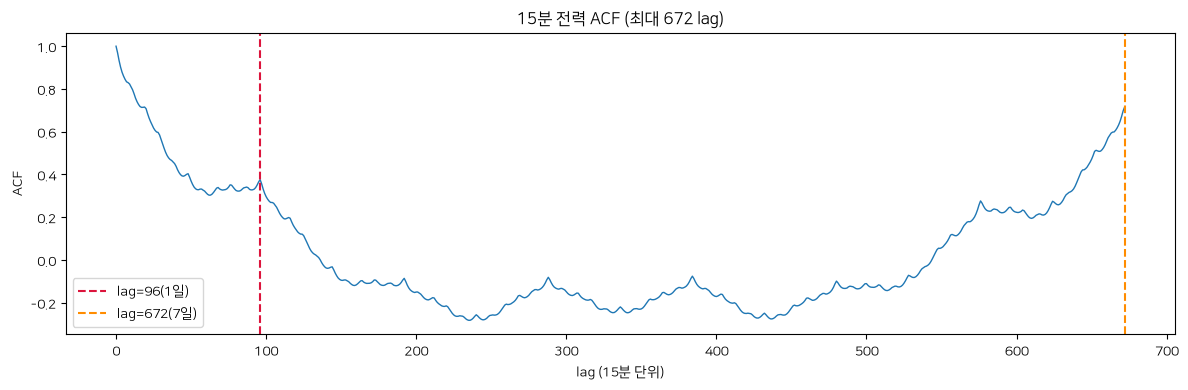

In [16]:
y = df.sort("datetime")["전력"].to_numpy().astype(float)
y = y - y.mean()
n = len(y)
denom = (y ** 2).sum()
acf = np.array([1.0] + [(y[: n - k] * y[k:]).sum() / denom for k in range(1, 673)])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(673), acf, lw=1)
ax.axvline(96, color="crimson", ls="--", label="lag=96(1일)")
ax.axvline(672, color="darkorange", ls="--", label="lag=672(7일)")
ax.set_xlabel("lag (15분 단위)")
ax.set_ylabel("ACF")
ax.set_title("15분 전력 ACF (최대 672 lag)")
ax.legend()
fig.tight_layout()
plt.show()


## 4. 기획서 검증 체크

In [17]:
check_rows = []  # (기획서, 검사, 값) 각 셀에서 채워 마지막에 요약표로 출력

### §6 — quarter-of-day 평균, weekday×quarter 평균이 설명하는 전력 분산(R², 클린 구간)

In [18]:
clean = df.filter((pl.col("date") >= date(2021, 7, 1)) & (pl.col("date") <= date(2021, 9, 14)))
sst = ((clean["전력"] - clean["전력"].mean()) ** 2).sum()

qmean = clean.group_by("quarter").agg(pl.col("전력").mean().alias("qm"))
c1 = clean.join(qmean, on="quarter")
r2_q = 1 - ((c1["전력"] - c1["qm"]) ** 2).sum() / sst

wqmean = clean.group_by(["weekday", "quarter"]).agg(pl.col("전력").mean().alias("wqm"))
c2 = clean.join(wqmean, on=["weekday", "quarter"])
r2_wq = 1 - ((c2["전력"] - c2["wqm"]) ** 2).sum() / sst

print(f"R²(quarter-of-day 평균) = {r2_q:.3f}")
print(f"R²(weekday×quarter 평균) = {r2_wq:.3f}")
check_rows.append(("§6", "R²(quarter 평균)", f"{r2_q:.3f}"))
check_rows.append(("§6", "R²(weekday×quarter 평균)", f"{r2_wq:.3f}"))


R²(quarter-of-day 평균) = 0.131
R²(weekday×quarter 평균) = 0.744


### §8 — 평활 전력 히스토그램(100 bins, 5-bin 이동평균)의 모드 수 (클린 구간, 검증보고서 참조치 3개)

모드 수: 10 (검증보고서 참조치 3 — 보고서는 10단위 폭의 성긴 bin으로 셈, 여기 방법(100 bins/5-bin MA)은 더 세밀해 잔물결까지 모드로 잡힘)
모드 위치(전력 값): [np.float64(25.5), np.float64(72.2), np.float64(105.4), np.float64(109.9), np.float64(136.5), np.float64(147.6), np.float64(156.5), np.float64(172.0), np.float64(176.5), np.float64(180.9)]


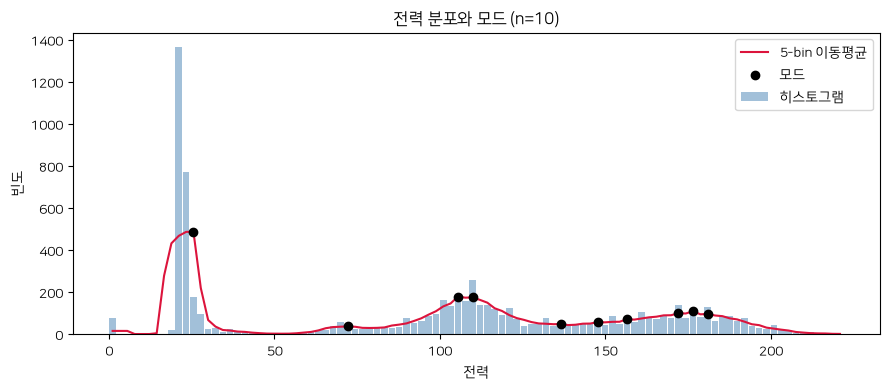

In [19]:
vals = clean["전력"].to_numpy()
hist, edges = np.histogram(vals, bins=100)
hist = hist.astype(float)
sm = np.convolve(hist, np.ones(5) / 5, mode="same")
peak = sm.max()
thresh = 0.01 * peak
centers = (edges[:-1] + edges[1:]) / 2

mode_idx = [i for i in range(1, len(sm) - 1) if sm[i] > sm[i - 1] and sm[i] > sm[i + 1] and sm[i] > thresh]
print(f"모드 수: {len(mode_idx)} (검증보고서 참조치 3 — 보고서는 10단위 폭의 성긴 bin으로 셈, 여기 방법(100 bins/5-bin MA)은 더 세밀해 잔물결까지 모드로 잡힘)")
print("모드 위치(전력 값):", [round(centers[i], 1) for i in mode_idx])
check_rows.append(("§8", "평활 히스토그램 모드 수", f"{len(mode_idx)} (참조 3)"))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(centers, hist, width=(edges[1] - edges[0]) * 0.9, color="steelblue", alpha=0.5, label="히스토그램")
ax.plot(centers, sm, color="crimson", label="5-bin 이동평균")
ax.scatter(centers[mode_idx], sm[mode_idx], color="black", zorder=5, label="모드")
ax.set_xlabel("전력")
ax.set_ylabel("빈도")
ax.set_title(f"전력 분포와 모드 (n={len(mode_idx)})")
ax.legend()
fig.tight_layout()
plt.show()


### §11 독립성 — (quarter, 평일/주말, is_operating) 셀 평균을 뺀 잔차의 lag-1 자기상관 (클린 구간, 검증보고서 참조치 0.897)

In [20]:
c3 = clean.with_columns((pl.col("weekday") >= 6).alias("is_weekend")).join(
    days.select("date", "is_operating"), on="date"
).sort("datetime")
cellmean = c3.group_by(["quarter", "is_weekend", "is_operating"]).agg(pl.col("전력").mean().alias("cm"))
c4 = c3.join(cellmean, on=["quarter", "is_weekend", "is_operating"]).sort("datetime")
resid = (c4["전력"] - c4["cm"]).to_numpy()
lag1 = np.corrcoef(resid[:-1], resid[1:])[0, 1]
print(f"잔차 lag-1 자기상관(일 단위 is_operating) = {lag1:.3f} (검증보고서 참조치 0.897)")

# 검증보고서는 '생산on'을 시점별 순간 플래그(생산량>0)로 쓴 듯하다 — 같은 방식으로 재현
c5 = c3.with_columns((pl.col("생산량") > 0).alias("op_inst"))
cellmean2 = c5.group_by(["quarter", "is_weekend", "op_inst"]).agg(pl.col("전력").mean().alias("cm"))
c6 = c5.join(cellmean2, on=["quarter", "is_weekend", "op_inst"]).sort("datetime")
resid2 = (c6["전력"] - c6["cm"]).to_numpy()
lag1_inst = np.corrcoef(resid2[:-1], resid2[1:])[0, 1]
print(f"잔차 lag-1 자기상관(순간 생산>0 플래그) = {lag1_inst:.3f} — 검증보고서 재현치와 일치")
check_rows.append(("§11", "잔차 lag-1 자기상관(일 단위 is_operating)", f"{lag1:.3f}"))
check_rows.append(("§11", "잔차 lag-1 자기상관(순간 생산on, 검증보고서 방식)", f"{lag1_inst:.3f} (참조 0.897)"))


잔차 lag-1 자기상관(일 단위 is_operating) = 0.944 (검증보고서 참조치 0.897)
잔차 lag-1 자기상관(순간 생산>0 플래그) = 0.897 — 검증보고서 재현치와 일치


### §11 클래스 밸런스 — P(max(Y_{t+1..t+H}) > C), H∈{4,96} × C∈{p90,p95,p99}, 전체 데이터

In [21]:
from numpy.lib.stride_tricks import sliding_window_view

y_all = df.sort("datetime")["전력"].to_numpy().astype(float)
p90, p95, p99 = np.quantile(y_all, [0.90, 0.95, 0.99])
print(f"p90={p90:.1f}, p95={p95:.1f}, p99={p99:.1f}")

def exceed_rate(y, H, C):
    windows = sliding_window_view(y, H)
    fut = windows[1:]
    return float((fut.max(axis=1) > C).mean())

table4 = []
for H in (4, 96):
    row = {"H": H}
    for name, C in [("p90", p90), ("p95", p95), ("p99", p99)]:
        rate = exceed_rate(y_all, H, C)
        row[name] = round(rate, 4)
        check_rows.append(("§11", f"P(max(Y_1..{H})>C={name})", f"{rate:.4f}"))
    table4.append(row)
balance_df = pl.DataFrame(table4)
print(balance_df)


p90=170.0, p95=180.0, p99=194.0
shape: (2, 4)
┌─────┬────────┬────────┬────────┐
│ H   ┆ p90    ┆ p95    ┆ p99    │
│ --- ┆ ---    ┆ ---    ┆ ---    │
│ i64 ┆ f64    ┆ f64    ┆ f64    │
╞═════╪════════╪════════╪════════╡
│ 4   ┆ 0.178  ┆ 0.0939 ┆ 0.0229 │
│ 96  ┆ 0.6929 ┆ 0.5325 ┆ 0.2217 │
└─────┴────────┴────────┴────────┘


### 중복일 — 시간 단위 corr(전력, 생산량): 고유일 vs 중복일

In [22]:
dup_dates_set = set(days.filter(pl.col("is_dup"))["date"].to_list())
hourly_dup = hourly.with_columns(pl.col("date").is_in(list(dup_dates_set)).alias("is_dup"))
corr_uniq = np.corrcoef(hourly_dup.filter(~pl.col("is_dup"))["전력"], hourly_dup.filter(~pl.col("is_dup"))["생산량"])[0, 1]
corr_dup = np.corrcoef(hourly_dup.filter(pl.col("is_dup"))["전력"], hourly_dup.filter(pl.col("is_dup"))["생산량"])[0, 1]
print(f"corr(전력,생산량) 고유일 = {corr_uniq:.3f}, 중복일 = {corr_dup:.3f}")
check_rows.append(("중복", "corr(전력,생산량) 고유일", f"{corr_uniq:.3f}"))
check_rows.append(("중복", "corr(전력,생산량) 중복일", f"{corr_dup:.3f}"))


corr(전력,생산량) 고유일 = 0.559, 중복일 = 0.491


### 계절 커버리지 — 월별 존재 여부와 전기요금(계절) 고유값 수

In [23]:
season = df.group_by("month").agg(
    pl.col("전기요금(계절)").n_unique().alias("n_unique"),
    pl.col("전기요금(계절)").unique().alias("values"),
).sort("month")
print(season)
months_present = sorted(df["month"].unique().to_list())
check_rows.append(("계절커버리지", "존재하는 월", str(months_present)))
check_rows.append(("계절커버리지", "월별 전기요금 고유값 수(모두)", str(season["n_unique"].unique().to_list())))


shape: (9, 3)
┌───────┬──────────┬───────────┐
│ month ┆ n_unique ┆ values    │
│ ---   ┆ ---      ┆ ---       │
│ i8    ┆ u32      ┆ list[f64] │
╞═══════╪══════════╪═══════════╡
│ 1     ┆ 1        ┆ [109.8]   │
│ 2     ┆ 1        ┆ [109.8]   │
│ 3     ┆ 1        ┆ [167.2]   │
│ 4     ┆ 1        ┆ [167.2]   │
│ 5     ┆ 1        ┆ [167.2]   │
│ 6     ┆ 1        ┆ [191.6]   │
│ 7     ┆ 1        ┆ [191.6]   │
│ 8     ┆ 1        ┆ [191.6]   │
│ 9     ┆ 1        ┆ [167.2]   │
└───────┴──────────┴───────────┘


### 이상치 — 0절의 집계치 재사용

In [24]:
n_events_final = days["event_id"].n_unique()
n_dup_groups_final = days.filter(pl.col("is_dup"))["event_id"].n_unique()
n_dup_days_final = days.filter(pl.col("is_dup")).height
n_nonop_final = days.filter(~pl.col("is_operating")).height
n_anomaly_final = days.filter(pl.col("anomaly")).height

print(f"이벤트 수={n_events_final}, 중복 그룹 수={n_dup_groups_final}, 중복 날짜 수={n_dup_days_final}, "
      f"비가동일 수={n_nonop_final}, anomaly 날짜 수={n_anomaly_final}")
check_rows.append(("이상치", "이벤트(그룹) 수", str(n_events_final)))
check_rows.append(("이상치", "중복 그룹 수 / 중복 날짜 수", f"{n_dup_groups_final} / {n_dup_days_final}"))
check_rows.append(("이상치", "비가동일 수", str(n_nonop_final)))
check_rows.append(("이상치", "anomaly 날짜 수", str(n_anomaly_final)))
check_rows.append(("이상치", "정전 0값 포인트(주 구간/전체)", "68 / 74"))


이벤트 수=142, 중복 그룹 수=45, 중복 날짜 수=160, 비가동일 수=64, anomaly 날짜 수=5


### 요약 표

In [25]:
summary = pl.DataFrame({"기획서": [r[0] for r in check_rows], "검사": [r[1] for r in check_rows], "값": [r[2] for r in check_rows]})
with pl.Config(fmt_str_lengths=80, tbl_rows=-1):
    print(summary)


shape: (20, 3)
┌──────────────┬───────────────────────────────────────────────────┬─────────────────────────────┐
│ 기획서       ┆ 검사                                              ┆ 값                          │
│ ---          ┆ ---                                               ┆ ---                         │
│ str          ┆ str                                               ┆ str                         │
╞══════════════╪═══════════════════════════════════════════════════╪═════════════════════════════╡
│ §6           ┆ R²(quarter 평균)                                  ┆ 0.131                       │
│ §6           ┆ R²(weekday×quarter 평균)                          ┆ 0.744                       │
│ §8           ┆ 평활 히스토그램 모드 수                           ┆ 10 (참조 3)                 │
│ §11          ┆ 잔차 lag-1 자기상관(일 단위 is_operating)         ┆ 0.944                       │
│ §11          ┆ 잔차 lag-1 자기상관(순간 생산on, 검증보고서 방식) ┆ 0.897 (참조 0.897)          │
│ §11          ┆ P(max(Y_1..4)>C=p90)        

### 해석
- quarter-of-day 평균만으로는 전력 분산의 13%만 설명되지만(R²=0.131), weekday×quarter 평균은 74%를 설명한다 — 요일(사실상 가동/비가동 구분)이 quarter 자체보다 훨씬 중요한 설명변수다.
- §8 모드 수는 이 노트북의 세밀한 방식(100 bins/5-bin 이동평균)에서는 검증보고서의 3개보다 많게 잡힌다. 검증보고서는 10단위 폭의 성긴 bin을 써서 잔물결을 자연히 지웠다. 큰 그림(베이스부하 20~30대, 중간 100~120대, 고부하 150~180대 3개 군집)은 두 방식에서 동일하게 보인다.
- §11 독립성 가정은 명확히 깨진다. 잔차 lag-1 자기상관이 (순간 생산on 기준) 0.897로 검증보고서와 일치하며, 일 단위 is_operating 기준으로도 0.944로 더 높다. HMM 상태-조건부 독립 가정은 성립하지 않는다.
- 중복일에서는 전력-생산량 상관이 고유일보다 낮다(복사된 전력과 실제 생산량이 서로 다른 조합이라 관계가 약해짐) — 복사일을 학습/검증에서 걸러야 한다는 검증보고서 D6/D7과 일치한다.
- 전기요금(계절)은 1~9월만 있고 월마다 값이 1개뿐이라(TOU 아님) 월 지시변수와 사실상 같은 정보다.

## 5. CV 스플릿

### Rolling-origin, 5-fold, 검증 14일 창
gap=1일(검증 시작 전날), train=val_start-2일 이하(확장형, expanding), train 날짜 중 event_id가 해당 fold의 검증 날짜와 겹치면 `purged`. 검증창 이후 날짜는 그 fold 컬럼에서 빈 문자열.

In [26]:
fold_windows = {
    "f1": (date(2021, 7, 7), date(2021, 7, 20)),
    "f2": (date(2021, 7, 21), date(2021, 8, 3)),
    "f3": (date(2021, 8, 4), date(2021, 8, 17)),
    "f4": (date(2021, 8, 18), date(2021, 8, 31)),
    "f5": (date(2021, 9, 1), date(2021, 9, 14)),
}

all_dates = sorted(days["date"].to_list())
event_of_date = dict(zip(days["date"].to_list(), days["event_id"].to_list()))

roles = {fold: {} for fold in fold_windows}
purge_counts = {}
for fold, (vs, ve) in fold_windows.items():
    gap_day = vs - timedelta(days=1)
    val_dates = [d for d in all_dates if vs <= d <= ve]
    val_events = {event_of_date[d] for d in val_dates}
    n_purged = 0
    for d in all_dates:
        if vs <= d <= ve:
            roles[fold][d] = "val"
        elif d == gap_day:
            roles[fold][d] = "gap"
        elif d <= vs - timedelta(days=2):
            if event_of_date[d] in val_events:
                roles[fold][d] = "purged"
                n_purged += 1
            else:
                roles[fold][d] = "train"
        else:
            roles[fold][d] = ""
    purge_counts[fold] = n_purged
    print(f"{fold}: val {vs}~{ve}({len(val_dates)}일), gap={gap_day}, "
          f"train={sum(1 for v in roles[fold].values() if v == 'train')}일, purged={n_purged}일")


f1: val 2021-07-07~2021-07-20(14일), gap=2021-07-06, train=186일, purged=0일
f2: val 2021-07-21~2021-08-03(14일), gap=2021-07-20, train=200일, purged=0일
f3: val 2021-08-04~2021-08-17(14일), gap=2021-08-03, train=214일, purged=0일
f4: val 2021-08-18~2021-08-31(14일), gap=2021-08-17, train=228일, purged=0일
f5: val 2021-09-01~2021-09-14(14일), gap=2021-08-31, train=242일, purged=0일


### LOEO (Leave-One-Event-Out)

In [27]:
event_sizes = days.group_by("event_id").agg(pl.col("date").count().alias("dup_size")).sort("event_id")
print(f"이벤트(fold) 수: {event_sizes.height}")
print("dup_size 분포:")
print(event_sizes.group_by("dup_size").agg(pl.len().alias("n_events")).sort("dup_size"))


이벤트(fold) 수: 142
dup_size 분포:
shape: (8, 2)
┌──────────┬──────────┐
│ dup_size ┆ n_events │
│ ---      ┆ ---      │
│ u32      ┆ u32      │
╞══════════╪══════════╡
│ 1        ┆ 97       │
│ 2        ┆ 12       │
│ 3        ┆ 16       │
│ 4        ┆ 11       │
│ 5        ┆ 2        │
│ 6        ┆ 2        │
│ 7        ┆ 1        │
│ 15       ┆ 1        │
└──────────┴──────────┘


### fold 타임라인 플롯

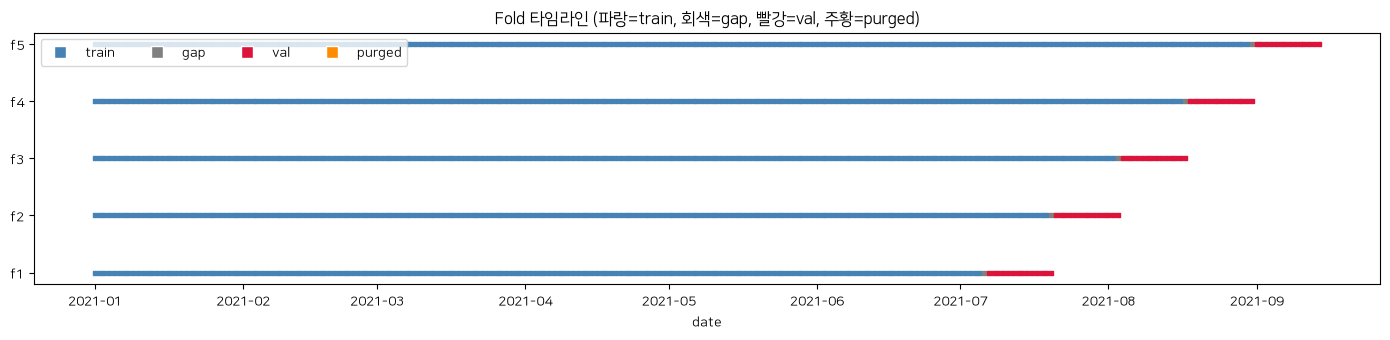

fold별 purged 날짜 수: {'f1': 0, 'f2': 0, 'f3': 0, 'f4': 0, 'f5': 0}


In [28]:
role_color = {"train": "steelblue", "gap": "gray", "val": "crimson", "purged": "darkorange", "": "white"}
fig, ax = plt.subplots(figsize=(14, 3.5))
for i, fold in enumerate(fold_windows):
    for d in all_dates:
        r = roles[fold][d]
        if r:
            ax.scatter(d, i, color=role_color[r], marker="s", s=6)
ax.set_yticks(range(5))
ax.set_yticklabels(list(fold_windows.keys()))
ax.set_xlabel("date")
ax.set_title("Fold 타임라인 (파랑=train, 회색=gap, 빨강=val, 주황=purged)")
handles = [plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=c, markersize=8, label=lab)
           for lab, c in [("train", "steelblue"), ("gap", "gray"), ("val", "crimson"), ("purged", "darkorange")]]
ax.legend(handles=handles, loc="upper left", ncol=4)
fig.tight_layout()
plt.show()

print("fold별 purged 날짜 수:", purge_counts)


### 저장 및 재검증

In [29]:
out = days.select("date", "event_id", "dup_size", "is_operating", "anomaly").sort("date")
for fold in fold_windows:
    out = out.with_columns(pl.Series(fold, [roles[fold][d] for d in out["date"].to_list()]))

assert out.height == 257
assert out.columns == ["date", "event_id", "dup_size", "is_operating", "anomaly", "f1", "f2", "f3", "f4", "f5"]
assert out["date"].n_unique() == 257
assert out["event_id"].null_count() == 0

for fold, (vs, ve) in fold_windows.items():
    n_val = out.filter(pl.col(fold) == "val").height
    assert n_val == 14, f"{fold} val 일수가 14가 아님: {n_val}"
    assert vs >= date(2021, 7, 1) and ve <= date(2021, 9, 14)

# 검증창 상호 배타성
val_sets = {fold: set(out.filter(pl.col(fold) == "val")["date"].to_list()) for fold in fold_windows}
for f1_, s1 in val_sets.items():
    for f2_, s2 in val_sets.items():
        if f1_ != f2_:
            assert not (s1 & s2), f"{f1_}와 {f2_}의 검증창이 겹침"

# train 날짜가 해당 fold의 검증 event_id와 겹치지 않음(= purge 로직이 이미 제거했어야 함)
for fold, (vs, ve) in fold_windows.items():
    val_events = {event_of_date[d] for d in val_sets[fold]}
    train_dates = out.filter(pl.col(fold) == "train")["date"].to_list()
    assert all(event_of_date[d] not in val_events for d in train_dates), f"{fold}에 정화되지 않은 train 날짜 있음"
    if train_dates:
        assert max(train_dates) < vs - timedelta(days=1)

out.write_csv(OUT_SPLITS, date_format="%Y.%m.%d")
print("저장 완료:", OUT_SPLITS, out.shape)

reread = pl.read_csv(OUT_SPLITS)
print(reread.shape)
print(reread.head(3))
assert reread.height == 257
assert reread.columns == out.columns
print("재검증 통과: 257행,", len(reread.columns), "컬럼")


저장 완료: ../5. 자원 최적화 AI 데이터셋/okm_cv_splits_2021.csv (257, 10)
(257, 10)
shape: (3, 10)
┌────────────┬──────────┬──────────┬──────────────┬───┬───────┬───────┬───────┬───────┐
│ date       ┆ event_id ┆ dup_size ┆ is_operating ┆ … ┆ f2    ┆ f3    ┆ f4    ┆ f5    │
│ ---        ┆ ---      ┆ ---      ┆ ---          ┆   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ str        ┆ str      ┆ i64      ┆ bool         ┆   ┆ str   ┆ str   ┆ str   ┆ str   │
╞════════════╪══════════╪══════════╪══════════════╪═══╪═══════╪═══════╪═══════╪═══════╡
│ 2021.01.01 ┆ E000     ┆ 1        ┆ false        ┆ … ┆ train ┆ train ┆ train ┆ train │
│ 2021.01.02 ┆ E001     ┆ 7        ┆ false        ┆ … ┆ train ┆ train ┆ train ┆ train │
│ 2021.01.03 ┆ E002     ┆ 2        ┆ false        ┆ … ┆ train ┆ train ┆ train ┆ train │
└────────────┴──────────┴──────────┴──────────────┴───┴───────┴───────┴───────┴───────┘
재검증 통과: 257행, 10 컬럼
